# Labeling anomalious days


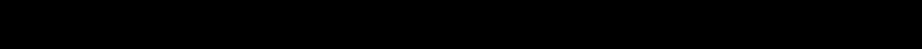
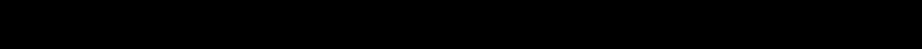
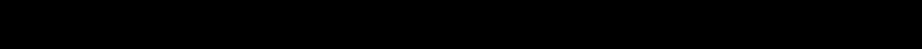

In [2]:
import os
import pandas as pd

In [3]:
daily_filtered = pd.read_parquet("../data/processed/chain/scam_daily_cleaned.parquet")

In [4]:
key_features = [
    'normal_sent_cnt', 'normal_recv_cnt', 'normal_total_cnt',
    'eth_sent_sum', 'eth_recv_sum', 'eth_net_flow',
    'uniq_peers_cnt', 'sessions_cnt',
    'active_span_min', 'burst_max_tx_5m'
]

### Compute Expanding Z-score

In [5]:
# Sort for expanding stats
daily_filtered = (daily_filtered.sort_values(by=["address", "day"]).reset_index(drop=True))

# Expanding Z-score
z_df = pd.DataFrame(index=daily_filtered.index)
grouped = daily_filtered.groupby("address", group_keys=False)

for feature in key_features:
    stats = grouped[feature].expanding(min_periods=1).agg(["mean", "std"])
    stats = stats.reset_index(level=0, drop=True)

    std = stats["std"].fillna(0).replace(0, 1e-6)
    z_df[feature] = (daily_filtered[feature] - stats["mean"]) / std

# Combined anomaly score
daily_filtered["combined_z_score"] = z_df.abs().max(axis=1)

print("NaNs in combined_z_score:", daily_filtered["combined_z_score"].isna().sum())

print("Z-score computation complete")

NaNs in combined_z_score: 0
Z-score computation complete


### Filter to research period

In [6]:
daily_filtered["day"] = pd.to_datetime(daily_filtered["day"]).dt.date

daily_filtered = daily_filtered[
    (daily_filtered["day"] >= pd.to_datetime("2017-01-01").date()) &
    (daily_filtered["day"] <= pd.to_datetime("2021-11-01").date())
].copy()

print("Rows after filter:", len(daily_filtered))

Rows after filter: 160341


## Check threshold sensitivity

In [7]:
thresholds = [1.5, 2.0, 2.5, 3.0]

threshold_results = []

for t in thresholds:
    temp_labels = (daily_filtered["combined_z_score"] > t).astype(int)

    summary = daily_filtered.assign(is_anomalous=temp_labels) \
        .groupby("address")["is_anomalous"] \
        .sum() \
        .reset_index(name="anomaly_days")

    threshold_results.append({
        "threshold": t,
        "total_days": len(daily_filtered),
        "anomalous_days": temp_labels.sum(),
        "anomaly_day_ratio": temp_labels.mean(),
        "addresses_with_anomalies": (summary["anomaly_days"] > 0).sum()
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   threshold  total_days  anomalous_days  anomaly_day_ratio  \
0        1.5      160341           48093           0.299942   
1        2.0      160341           30046           0.187388   
2        2.5      160341           18755           0.116969   
3        3.0      160341           11872           0.074042   

   addresses_with_anomalies  
0                      3384  
1                      2771  
2                      2107  
3                      1684  


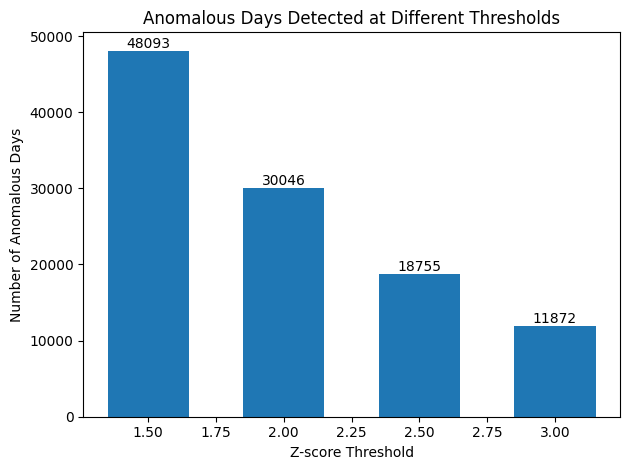

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(threshold_df['threshold'], threshold_df['anomalous_days'], width=0.3)

plt.xlabel('Z-score Threshold')
plt.ylabel('Number of Anomalous Days')
plt.title('Anomalous Days Detected at Different Thresholds')

plt.ylim(0, None)

for x, y in zip(threshold_df['threshold'], threshold_df['anomalous_days']):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.tight_layout()
plt.show()


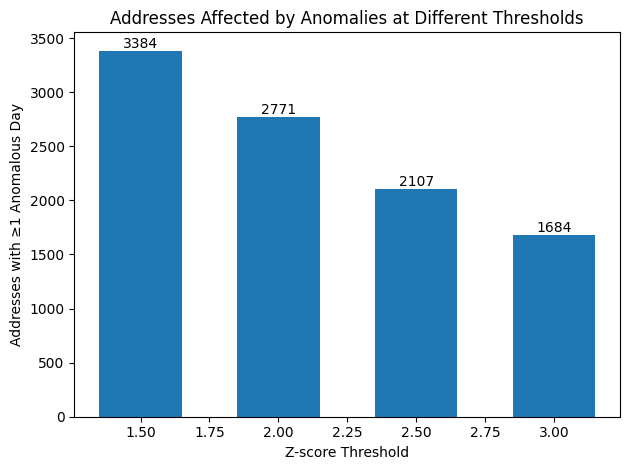

In [9]:
plt.figure()

plt.bar(threshold_df['threshold'], threshold_df['addresses_with_anomalies'], width=0.3)

plt.xlabel('Z-score Threshold')
plt.ylabel('Addresses with ≥1 Anomalous Day')
plt.title('Addresses Affected by Anomalies at Different Thresholds')

plt.ylim(0, None)

for x, y in zip(threshold_df['threshold'], threshold_df['addresses_with_anomalies']):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Label days


In [10]:
threshold = 2.0

# Label anomalies
daily_filtered["is_anomalous"] = (daily_filtered["combined_z_score"] > threshold).astype(int)
print("labeling complete")

# Per-address summary
summary_df = (daily_filtered.groupby("address").agg(total_active_days=("day", "count"), anomaly_days=("is_anomalous", "sum")).reset_index())

# Drop addresses with 0 anomalous days
valid_addresses = summary_df.loc[summary_df["anomaly_days"] > 0, "address"]

labeling complete


In [11]:
output_folder = "../data/processed/chain"
os.makedirs(output_folder, exist_ok=True)

daily_final = daily_filtered[daily_filtered["address"].isin(valid_addresses)].copy()
summary_final = summary_df[summary_df["address"].isin(valid_addresses)].copy()

anomalies_file = os.path.join(output_folder, "labeled_days.parquet")
summary_file = os.path.join(output_folder, "labeled_days_summary.csv")

daily_final.to_parquet(anomalies_file, index=False)
summary_final.to_csv(summary_file, index=False)

print(f"Saved anomalies file: {anomalies_file}")
print(f"Saved summary file: {summary_file}")

Saved anomalies file: ../data/processed/chain\labeled_days.parquet
Saved summary file: ../data/processed/chain\labeled_days_summary.csv


In [12]:
label_data = pd.read_csv("../data/processed/chain/labeled_days_summary.csv")

address_count = label_data["address"].nunique()
all_days = label_data["total_active_days"].sum()
unusual_days = label_data["anomaly_days"].sum()

normal_days = all_days - unusual_days
unusual_percentage = (unusual_days / all_days) * 100 if all_days > 0 else 0

print("Label Data Summary\n")
print(f"Address count: {address_count}")
print(f"All days: {all_days}")
print(f"Normal days: {normal_days}")
print(f"Unusual days: {unusual_days}")
print(f"anomaly percentage: {unusual_percentage:.2f}%")


Label Data Summary

Address count: 2771
All days: 144659
Normal days: 114613
Unusual days: 30046
anomaly percentage: 20.77%
